PIMA Diabetes Dataset — First 5 Rows
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigree  Age  Outcome  
0             0.627   50        1  
1             0.351   31        0  
2             0.672   32        1  
3             0.167   21        0  
4             2.288   33        1  

Shape: 768 rows × 9 columns

Data Types:
 Pregnancies           int64
Glucose               int64
BloodPressure         int64
SkinThickness         int64
Insulin               int64
BMI                 float64
DiabetesPedigree    float64
Age                   int64
Outcome               int64
dtype: object

Basi

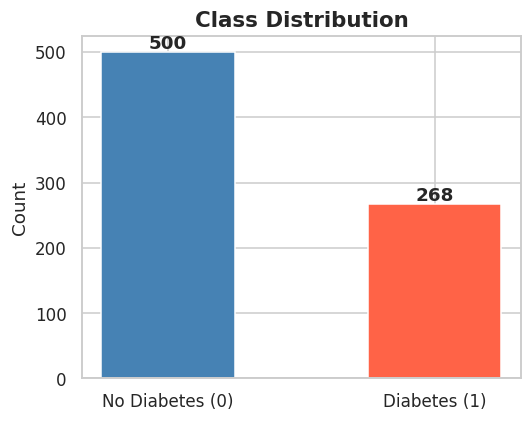

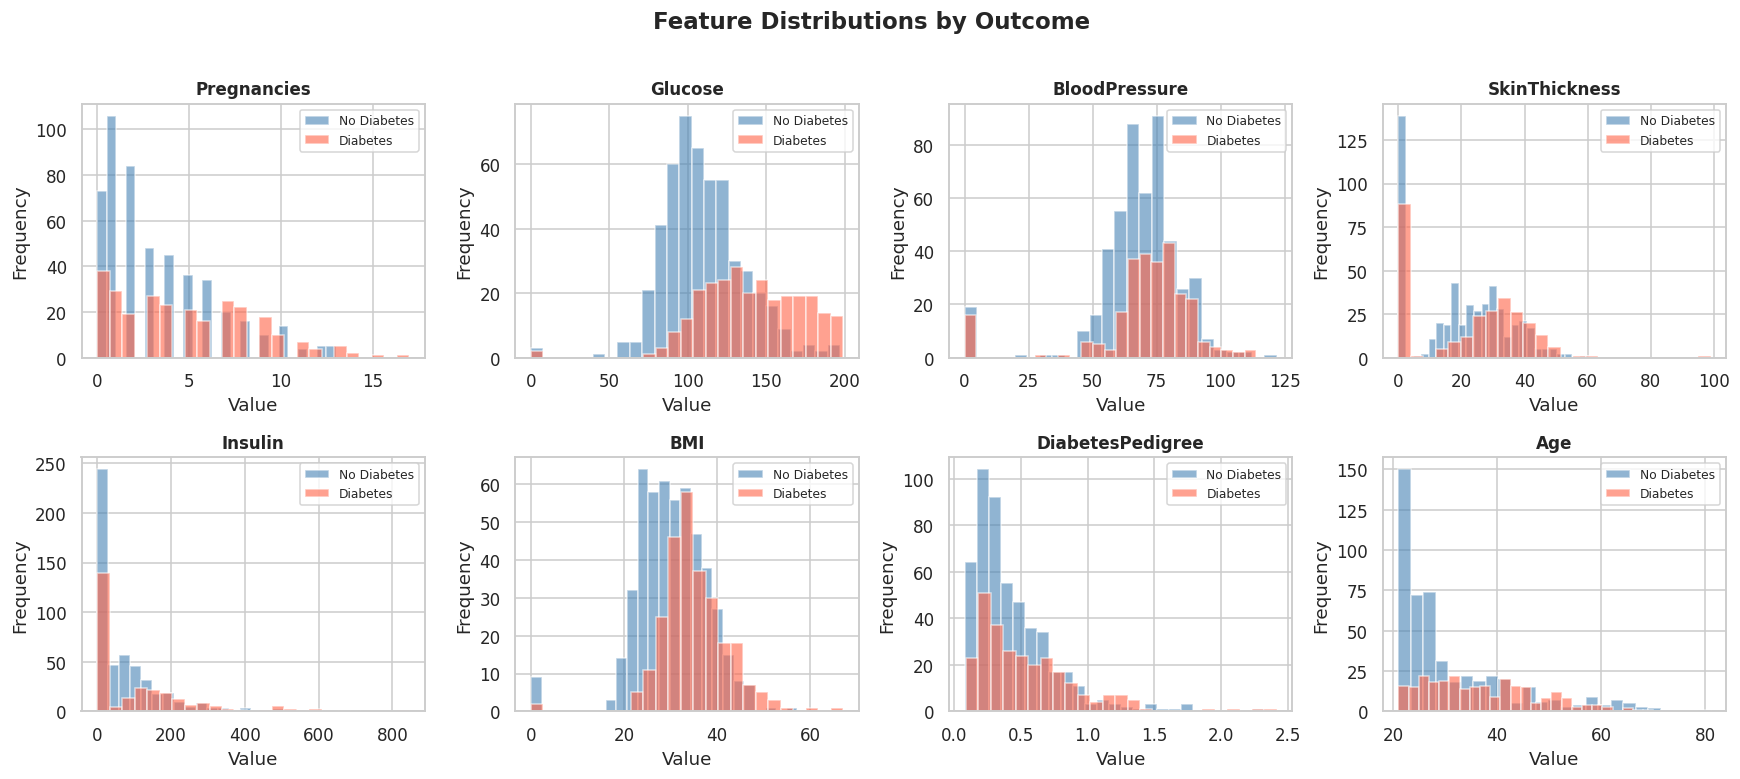

In [ ]:
# ============================================================
# Task 8: Diabetes Prediction with Logistic Regression
# Dataset: PIMA Indians Diabetes Dataset
# ============================================================

# --- Import Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)

# Set a consistent style for all plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

# ============================================================
# 1. LOAD DATA
# ============================================================

url = (
    "https://raw.githubusercontent.com/jbrownlee/Datasets/"
    "master/pima-indians-diabetes.csv"
)

column_names = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigree", "Age", "Outcome",
]

df = pd.read_csv(url, names=column_names)

print("=" * 55)
print("PIMA Diabetes Dataset — First 5 Rows")
print("=" * 55)
print(df.head())
print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nData Types:\n", df.dtypes)
print("\nBasic Statistics:")
print(df.describe())

# ============================================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# --- 2a. Class Balance ---
print("\n" + "=" * 55)
print("Class Balance (Outcome)")
print("=" * 55)
class_counts = df["Outcome"].value_counts()
print(class_counts)
print(f"\nNegative (0 = No Diabetes): {class_counts[0]}")
print(f"Positive (1 = Diabetes)   : {class_counts[1]}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(
    ["No Diabetes (0)", "Diabetes (1)"],
    class_counts.values,
    color=["steelblue", "tomato"],
    edgecolor="white",
    width=0.5,
)
ax.set_title("Class Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("Count")
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 5, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

# --- 2b. Feature Distributions ---
features = column_names[:-1]  # all columns except 'Outcome'

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(
        df[df["Outcome"] == 0][col],
        bins=25, alpha=0.6, label="No Diabetes", color="steelblue",
    )
    axes[i].hist(
        df[df["Outcome"] == 1][col],
        bins=25, alpha=0.6, label="Diabetes", color="tomato",
    )
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
    axes[i].legend(fontsize=8)

fig.suptitle("Feature Distributions by Outcome", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# --- 2